In [508]:
import confnotebook

In [509]:
from pathlib import Path

source = Path("../examples/test/full")

files = sorted(source.glob("*.pdf"))

for i, file in enumerate(files):
    print(f"[{i}] {file.stem}")

[0] 10
[1] 126164
[2] 14964427_Енисейская ТГК-13-БРАЗ
[3] 14976087_АвеларСолар Тех-БРАЗ-1
[4] 15120979_Форвард Энерго-БРАЗ-1
[5] 15235008_ОГК-2-БРАЗ-1
[6] 25
[7] 33
[8] 4
[9] 44
[10] 7-1
[11] Акт сверки взаимных расчетов №00000379931 от 30.04.2024
[12] Акт сверки №0000
[13] Акт сверки №MOW00-0087974   от 10.06.2024
[14] Акт сверки №ТРБП-000006 от 10.01.2024
[15] АС ВНИИМ Менделеева Д.И. - БРАЗ на 31.12.24
[16] АС ВНИИМ Менделеева Д.И. - РУ на 31.12.24
[17] АС КРЕЗОЛ-САЗ на 31.08.25
[18] АС Охрана Металлург-САЗ на 31.12.25
[19] АС РУ- ВОСЬМОЙ ВЕТРОПАРК
[20] АС Фрейт Линк-БРАЗ на 30.09.25
[21] АСР СДД 2 кв.2024 (подп. к-а)
[22] Браз-Юнигрин Пауэр
[23] документ 23-ИИА-03-01141 от 31_03_2025
[24] документ 23-ИИА-03-01142 от 31_03_2025
[25] ЕВР-НКАЗ
[26] Неформализованный_первичный_документ_23_ИИА_03_00342_от_31_03
[27] Неформализованный_первичный_документ_23_ИИА_03_02596_от_31_03
[28] Неформализованный_первичный_документ_23_ИИА_03_03623_от_31_03
[29] Неформализованный_первичный_до

In [510]:
IDX_FILE = 11
NUM_PAGE = 0

In [511]:
from vision_core.loader.pdf_loader import PDFLoader
from vision_core.pipelines.build_document import DocumentBuildPipeline
from vision_core.preprocessor.image_orientation import PageOrientationPreprocessor

build_pipeline = DocumentBuildPipeline()

img = PDFLoader(pdf_bytes=files[IDX_FILE].read_bytes()).get_page_image(page_num=NUM_PAGE, dpi=200)

img, _ = PageOrientationPreprocessor().process(img)
ocr_results, _ = build_pipeline._run_ocr(img)
print(ocr_results)

Creating model: ('PP-OCRv5_server_det', 'D:\\projects\\rusal_recon_srv\\repo\\recon_vision\\models\\PP-OCRv5_server_det')
Creating model: ('cyrillic_PP-OCRv5_mobile_rec', 'D:\\projects\\rusal_recon_srv\\repo\\recon_vision\\models\\cyrillic_PP-OCRv5_mobile_rec')
2026-07-17 00:09:33.368 | DEBUG    | vision_core.preprocessor.image_orientation:process:47 - Ориентация страницы: 0° с точностью 0.8540
2026-07-17 00:09:33.427 | DEBUG    | vision_core.preprocessor.image_orientation:compute_deskew_angle:119 - Углы наклона страницы: 0.0000°
2026-07-17 00:09:53.741 | DEBUG    | vision_core.pipelines.build_document:_run_ocr:240 - OCR: распознано 124 блоков, средняя уверенность: 0.98


[OcrResult(text='231041', confidence=0.9996439814567566, bbox=(np.int16(143), np.int16(86), np.int16(228), np.int16(114))), OcrResult(text='ISS071141', confidence=0.9874922633171082, bbox=(np.int16(1386), np.int16(84), np.int16(1505), np.int16(109))), OcrResult(text='Акт сверки', confidence=0.9655909538269043, bbox=(np.int16(743), np.int16(146), np.int16(919), np.int16(181))), OcrResult(text='взаимных расчетов № 379931 от 30.04.2024, за период с 01.04.2024 по 30.04.2024', confidence=0.9968017339706421, bbox=(np.int16(423), np.int16(179), np.int16(1237), np.int16(208))), OcrResult(text='между О00 "РН-Карт", ИНН/КПП 7743529527/772501001', confidence=0.9760306477546692, bbox=(np.int16(551), np.int16(206), np.int16(1111), np.int16(231))), OcrResult(text='и Акционерное общество "РЎСАЛ Ачинский Глиноземный Комбинат", ИНН/КПП 2443005570/997550001', confidence=0.9846200942993164, bbox=(np.int16(324), np.int16(230), np.int16(1337), np.int16(255))), OcrResult(text='по договору № 34560418/050098/

In [512]:
import cv2
import numpy as np
from matplotlib import pyplot as plt


def to_gray(img):
    if len(img.shape) == 3:
        return cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    else:
        return img

def gamma_LUT(gamma=1.2):
    inv = 1.0 / gamma
    table = (np.linspace(0, 1, 256) ** inv) * 255.0
    return table.astype("uint8")


def apply_gamma(img, gamma=1.2):
    table = gamma_LUT(gamma)
    return cv2.LUT(img, table)

sharpness_img = apply_gamma(img, gamma=0.3)

# cv2.imwrite(f"test_{IDX_FILE}.png", sharpness_img)

# plt.figure(figsize=(10, 10))
# plt.imshow(sharpness_img)
# plt.title("Processed Image")
# plt.axis("off")
# plt.show()

In [ ]:
def preprocess(sharpness_img):
    """Шаг 1: grayscale + blur + adaptive threshold -> бинарная маска (текст+линии)."""
    gray_img = to_gray(sharpness_img)
    blurred_img = cv2.GaussianBlur(gray_img, (5, 5), 0)
    bin_img = cv2.adaptiveThreshold(
        blurred_img, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV, 11, 2
    )
    return gray_img, bin_img


def extract_lines_mask(bin_img):
    """Шаг 2: MORPH_OPEN длинными осевыми ядрами -> убираем текст, оставляем линии сетки."""
    h, w = bin_img.shape

    vertical_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1, h // 40))
    horizontal_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (w // 10, 1))

    h_opened = cv2.morphologyEx(bin_img, cv2.MORPH_OPEN, horizontal_kernel)
    v_opened = cv2.morphologyEx(bin_img, cv2.MORPH_OPEN, vertical_kernel)

    mask = cv2.bitwise_or(h_opened, v_opened)
    return mask


def find_non_axis_lines(mask, angle_thresh=1.0, min_len_frac=0.1, hough_threshold=10, max_gap=30):
    """Шаг 3: HoughLinesP + фильтр по углу -> находим диагонали/артефакты скана."""
    lines = cv2.HoughLinesP(
        mask, 1, np.pi / 180, threshold=hough_threshold,
        minLineLength=int(min_len_frac * mask.shape[0]), maxLineGap=max_gap
    )

    diagonal_candidates = []
    if lines is not None:
        for l in lines:
            x1, y1, x2, y2 = l[0]
            angle = np.degrees(np.arctan2(y2 - y1, x2 - x1)) % 180
            is_axis_aligned = (
                angle < angle_thresh or angle > 180 - angle_thresh
                or abs(angle - 90) < angle_thresh
            )
            if not is_axis_aligned:
                diagonal_candidates.append((x1, y1, x2, y2))

    return diagonal_candidates

def remove_lines(mask, lines_to_remove, erase_thickness=3):
    """Стираем найденные диагонали."""
    mask_clean = mask.copy()
    for x1, y1, x2, y2 in lines_to_remove:
        cv2.line(mask_clean, (x1, y1), (x2, y2), 0, thickness=erase_thickness)
    return mask_clean

def repair_mask(mask, close_size=7):
    """MORPH_CLOSE -> срастить микроразрывы."""
    close_h = cv2.getStructuringElement(cv2.MORPH_RECT, (close_size, 1))
    close_v = cv2.getStructuringElement(cv2.MORPH_RECT, (1, close_size))

    mask_fixed = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, close_h)
    mask_fixed = cv2.morphologyEx(mask_fixed, cv2.MORPH_CLOSE, close_v)
    return mask_fixed

def in_bbox(ocr_bbox, table_bbox, min_overlap_ratio=0.5):
    """True, если доля площади ocr_bbox внутри table_bbox не меньше min_overlap_ratio."""
    ox0, oy0, ox1, oy1 = map(int, ocr_bbox)
    tx, ty, tw, th = table_bbox
    tx1, ty1 = tx + tw, ty + th

    ix0, iy0 = max(ox0, tx), max(oy0, ty)
    ix1, iy1 = min(ox1, tx1), min(oy1, ty1)
    inter = max(0, ix1 - ix0) * max(0, iy1 - iy0)

    ocr_area = max(0, ox1 - ox0) * max(0, oy1 - oy0)
    if ocr_area == 0:
        return False
    return (inter / ocr_area) >= min_overlap_ratio




def has_text_inside(table_bbox, ocr_results, min_confidence=0.8):
    """Проверяет, есть ли внутри table_bbox хотя бы один OCR-бокс с confidence >= min_confidence."""
    return any(
        r.confidence >= min_confidence and in_bbox(r.bbox, table_bbox)
        for r in ocr_results
    )

def find_table_candidates(mask_fixed, page_shape, ocr_results, min_area_frac=0.005, min_w=50, min_h=30, min_confidence=0.8):
    """Шаг 5: findContours + top-level (RETR_CCOMP) + фильтр по площади и наличию текста -> bbox'ы таблиц."""
    contours, hierarchy = cv2.findContours(mask_fixed, cv2.RETR_CCOMP, cv2.CHAIN_APPROX_SIMPLE)
    top_level = [c for c, h in zip(contours, hierarchy[0]) if h[3] == -1]

    page_h, page_w = page_shape
    table_candidates = []
    for c in top_level:
        x, y, w, h = cv2.boundingRect(c)
        if w > page_w * 0.95 and h > page_h * 0.95:
            continue  # рамка во всю страницу — не таблица
        area = w * h
        if area > min_area_frac * page_h * page_w and w > min_w and h > min_h:
            if has_text_inside((x, y, w, h), ocr_results, min_confidence=min_confidence):
                table_candidates.append((x, y, w, h))
    sorted_candidates = sorted(table_candidates, key=lambda bbox: (bbox[1], bbox[0]))  # сортировка по y, затем по x
    return sorted_candidates




def detect_table_candidates(sharpness_img, ocr_results, debug=False):
    """Полный пайплайн: sharpness_img -> список bbox'ов таблиц-кандидатов."""
    gray_img, bin_img = preprocess(sharpness_img)
    mask = extract_lines_mask(bin_img)
    diagonal_candidates = find_non_axis_lines(mask)
    mask_clean = remove_lines(mask, diagonal_candidates)
    mask_fixed = repair_mask(mask_clean)
    bin_img = remove_lines(bin_img, diagonal_candidates)
    table_candidates = find_table_candidates(mask_fixed, gray_img.shape, ocr_results)

    if debug:
        vis = cv2.cvtColor(bin_img, cv2.COLOR_GRAY2BGR)
        for i, (x, y, w, h) in enumerate(table_candidates):
            cv2.putText(vis, f"Table {i}", (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 0, 0), 3)
            cv2.rectangle(vis, (x, y), (x + w, y + h), (0, 0, 255), 2)
        plt.figure(figsize=(10, 10))
        plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
        plt.title(f"Table candidates: {len(table_candidates)}")
        plt.axis("off")
        plt.show()

    return table_candidates, {
        "gray_img": gray_img,
        "bin_img": bin_img,
        "mask": mask,
        "mask_fixed": mask_fixed,
        "diagonal_candidates": diagonal_candidates,
    }

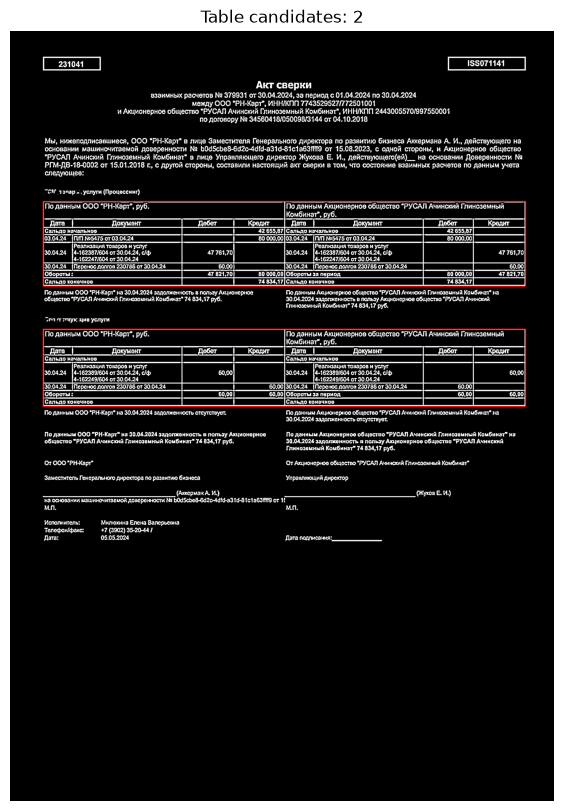

In [514]:
table_candidates, debug_data = detect_table_candidates(sharpness_img, ocr_results, debug=True)

найдем медианы высоты строк каждого кандидата таблиц

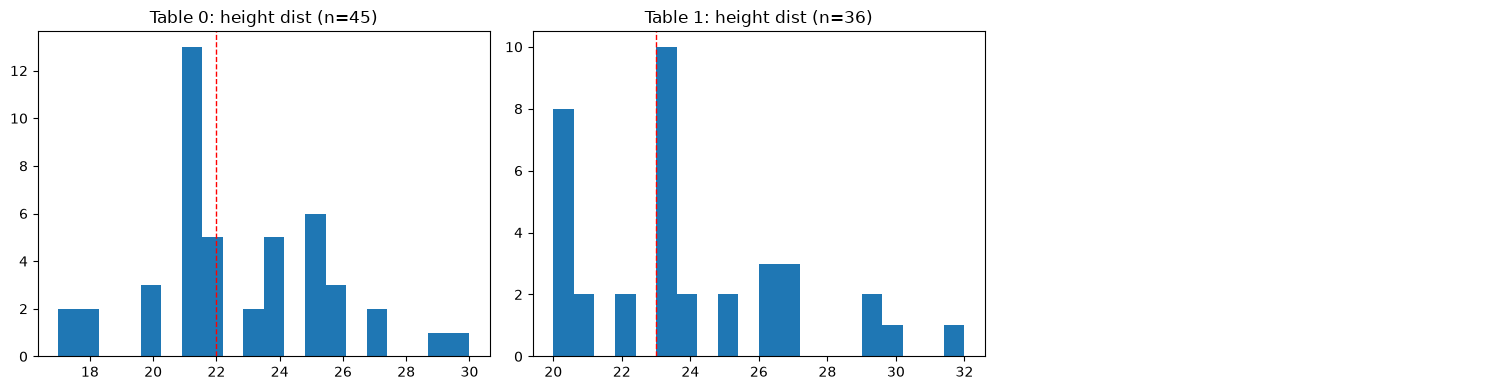

In [515]:
n = len(table_candidates)
cols = 3
rows = -(-n // cols)

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
axes = np.atleast_1d(axes).ravel()

list_median_heights = []

for i, (x, y, w, h) in enumerate(table_candidates):
    table_ocr = [r for r in ocr_results if in_bbox(r.bbox, (x, y, w, h))]
    heights = [r.bbox[3] - r.bbox[1] for r in table_ocr]
    median_height = np.median(heights)

    list_median_heights.append(median_height)

    ax = axes[i]
    ax.hist(heights, bins=20)
    # пунткирная линия медианы
    ax.axvline(median_height, color='r', linestyle='dashed', linewidth=1)
    ax.set_title(f"Table {i}: height dist (n={len(heights)})")

for j in range(n, len(axes)):
    axes[j].axis("off")

fig.tight_layout()
plt.show()

    


посмотрим на текстовые блоки внутри таблицы

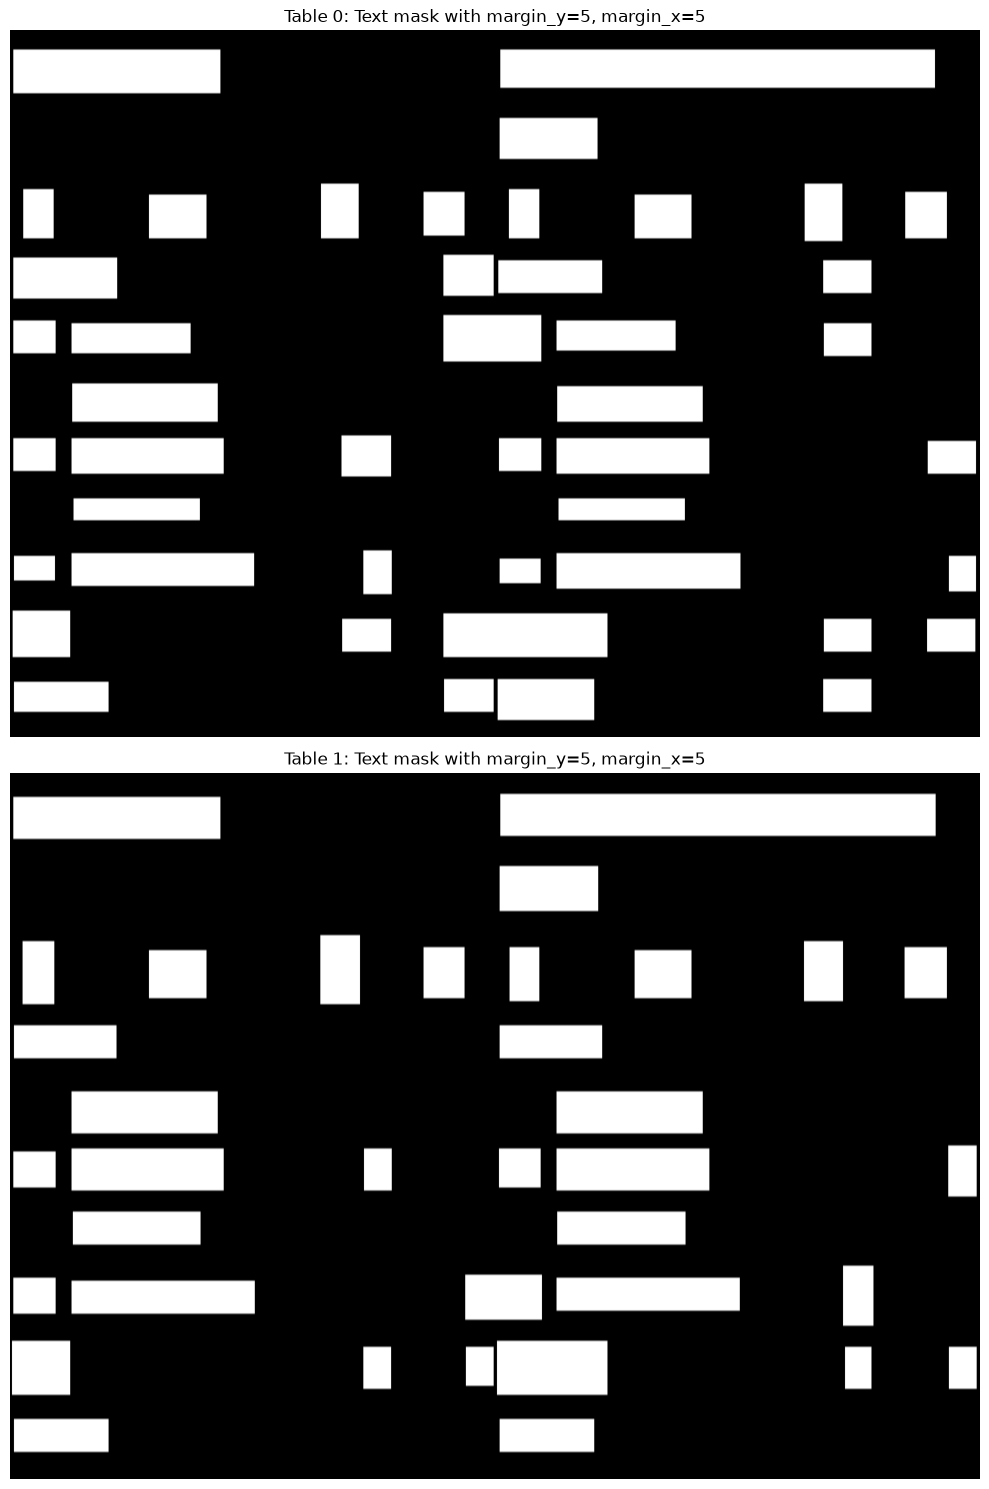

In [516]:
margin_y = 5  # пикселей отступ сверху/снизу
margin_x = 5  # пикселей отступ слева/справа

n = len(table_candidates)
fig, axes = plt.subplots(n, 1, figsize=(10, 15))
axes = np.atleast_1d(axes).ravel()

list_text_masks = []

for i, (x, y, w, h) in enumerate(table_candidates):
    table_ocr = [r for r in ocr_results if in_bbox(r.bbox, (x, y, w, h))]
    text_mask_inset = np.zeros((h, w), dtype=np.uint8)

    for r in table_ocr:
        ox0, oy0, ox1, oy1 = r.bbox
        lx0, ly0, lx1, ly1 = ox0 - x, oy0 - y, ox1 - x, oy1 - y

        # применяем отступ, не давая прямоугольнику схлопнуться в ноль
        ly0_in = ly0 + margin_y
        ly1_in = ly1 - margin_y
        lx0_in = lx0 + margin_x
        lx1_in = lx1 - margin_x

        # if ly1_in > ly0_in and lx1_in > lx0_in:
        cv2.rectangle(text_mask_inset, (lx0_in, ly0_in), (lx1_in, ly1_in), 255, thickness=-1)

    list_text_masks.append(text_mask_inset)
    
    ax = axes[i]
    ax.imshow(text_mask_inset, cmap="gray", aspect="auto")
    ax.set_title(f"Table {i}: Text mask with margin_y={margin_y}, margin_x={margin_x}")
    ax.axis("off")

fig.tight_layout()
plt.show()


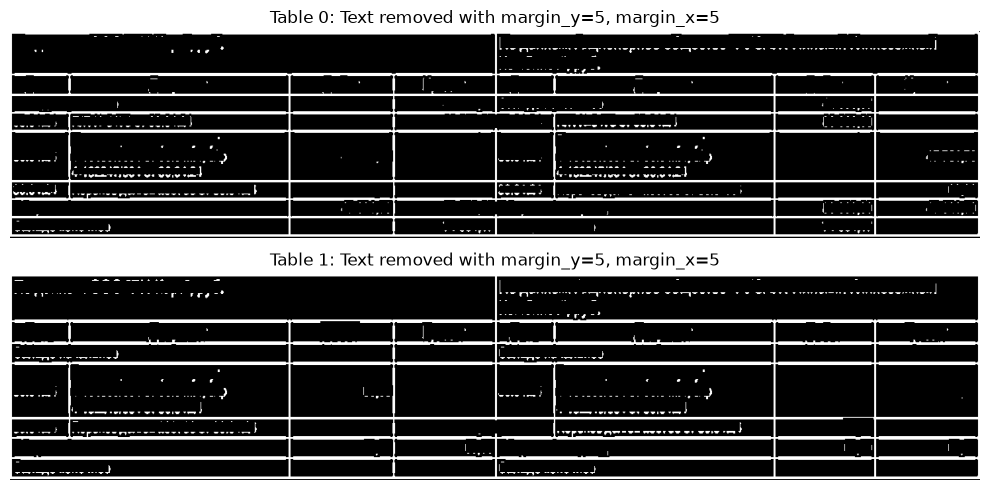

In [517]:
n = len(table_candidates)
fig, axes = plt.subplots(n, 1, figsize=(10, 5))
axes = np.atleast_1d(axes).ravel()

bin_img = debug_data['bin_img']
list_no_text = []
for i, ((x, y, w, h), text_mask_inset) in enumerate(zip(table_candidates, list_text_masks)):
    bin_crop = bin_img[y:y+h, x:x+w]
    # убираем текст: там, где text_mask=255, обнуляем bin_crop
    no_text = cv2.bitwise_and(bin_crop, cv2.bitwise_not(text_mask_inset))
    list_no_text.append(no_text)
    
    ax = axes[i]
    ax.imshow(no_text, cmap="gray", aspect="auto")
    ax.set_title(f"Table {i}: Text removed with margin_y={margin_y}, margin_x={margin_x}")
    ax.axis("off")

fig.tight_layout()
plt.show()

очистим маску морфологией

In [518]:
def keep_lines_with_intersections(v_mask, h_mask, dilate_size=5, min_length=15):
    """Оставляет компоненты v_mask/h_mask, которые одновременно
    достаточно длинные и пересекаются с перпендикулярной линией."""
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (dilate_size, dilate_size))
    h_dilated = cv2.dilate(h_mask, kernel)
    v_dilated = cv2.dilate(v_mask, kernel)

    def _filter(mask, dilated_other, is_vertical):
        n, labels, stats, _ = cv2.connectedComponentsWithStats(mask)
        keep = np.zeros_like(mask)
        for label in range(1, n):
            length = stats[label, cv2.CC_STAT_HEIGHT] if is_vertical else stats[label, cv2.CC_STAT_WIDTH]
            if length < min_length:
                continue
            comp = (labels == label).astype(np.uint8) * 255
            if cv2.countNonZero(cv2.bitwise_and(comp, dilated_other)) > 0:
                keep = cv2.bitwise_or(keep, comp)
        return keep

    v_keep = _filter(v_mask, h_dilated, is_vertical=True)
    h_keep = _filter(h_mask, v_dilated, is_vertical=False)

    return cv2.bitwise_or(v_keep, h_keep)


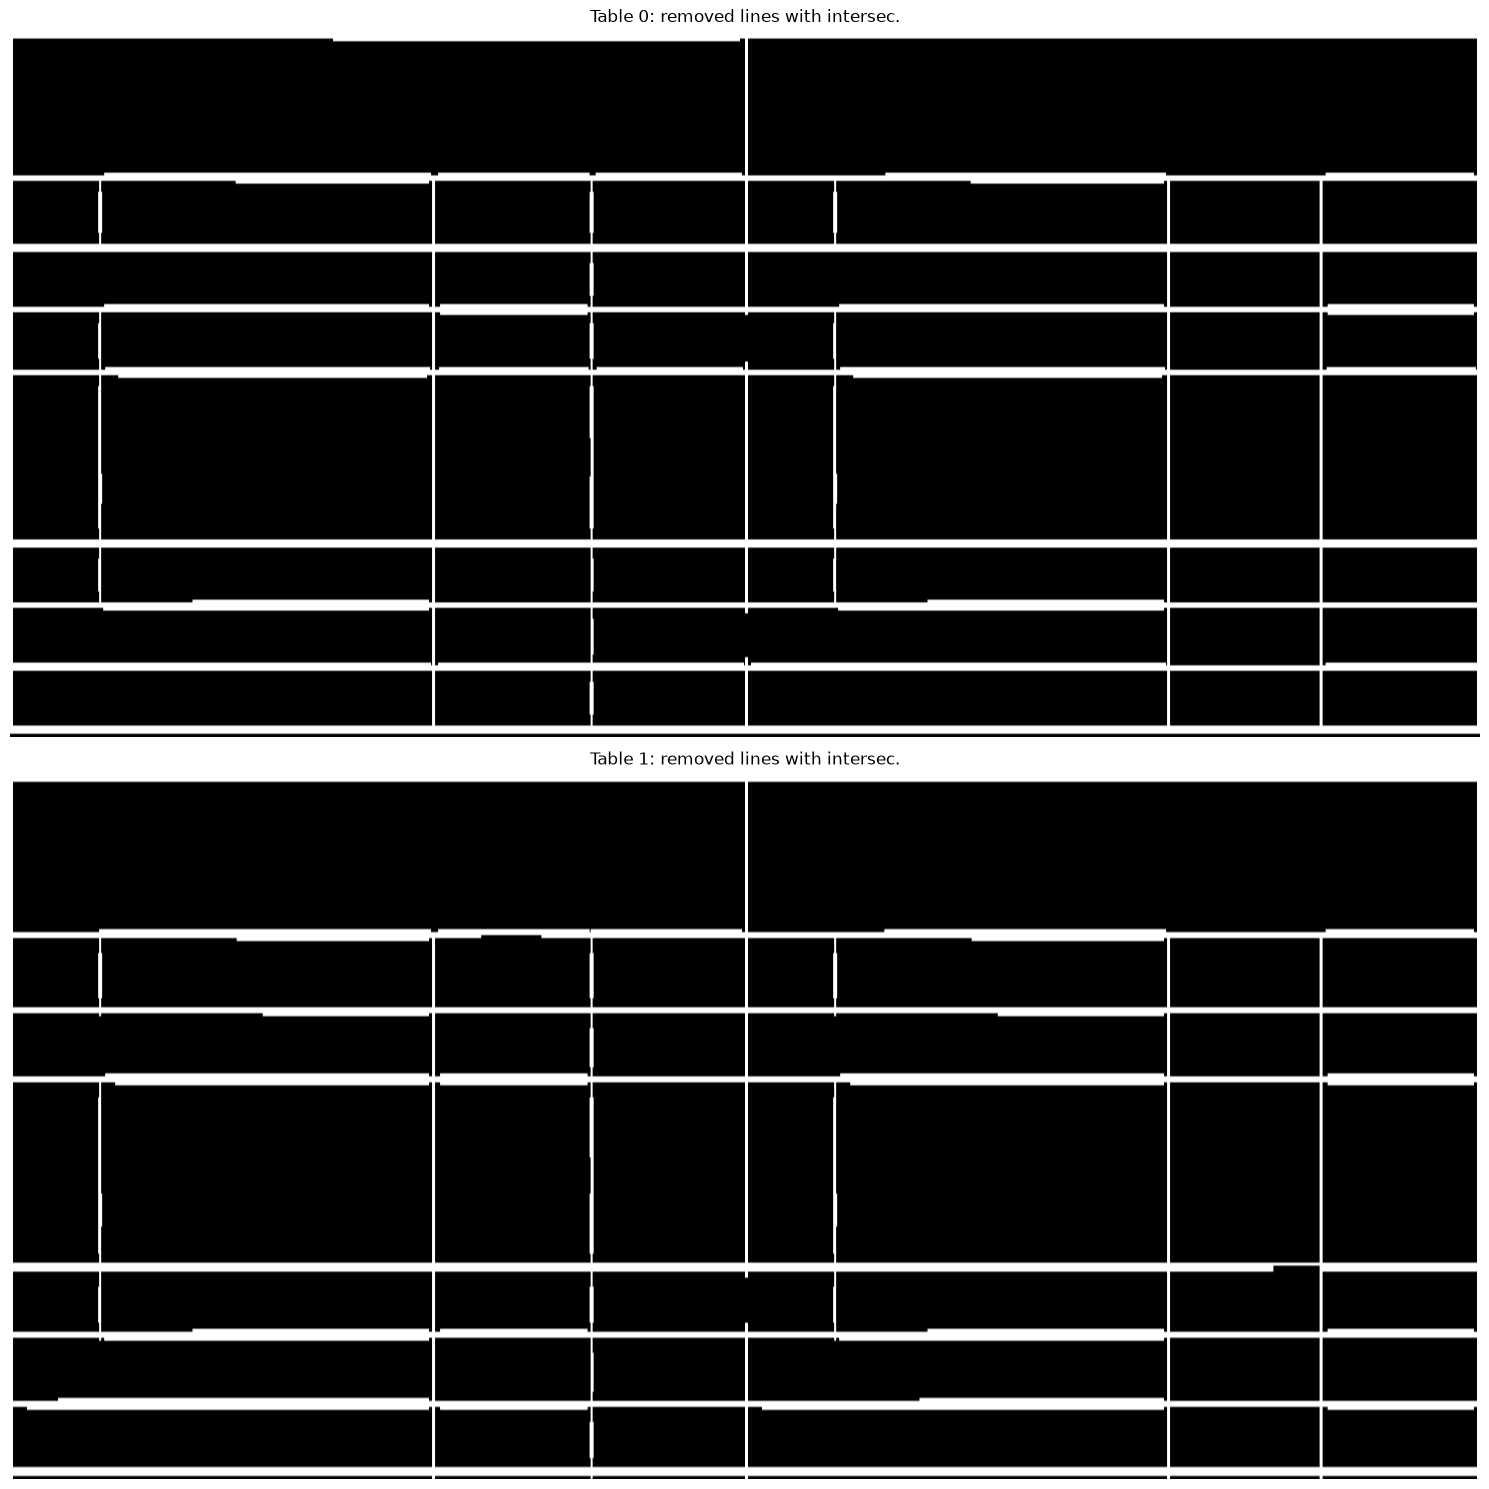

In [519]:
fig, axes = plt.subplots(n, 1, figsize=(15, 15))
axes = np.atleast_1d(axes).ravel()

list_mask_finaly = []

for i, ((x, y, w, h), crop, m) in enumerate(zip(table_candidates, list_no_text, list_median_heights)):
    crop_h, crop_w = crop.shape
    scale_factor = crop_h / m

    v_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1, int(scale_factor)))
    h_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (crop_w // 10, 1))

    v_mask = cv2.morphologyEx(crop, cv2.MORPH_OPEN, v_kernel)
    h_mask = cv2.morphologyEx(crop, cv2.MORPH_OPEN, h_kernel)
    mask_finaly = keep_lines_with_intersections(v_mask, h_mask, dilate_size=1, min_length=m)
    list_mask_finaly.append(mask_finaly)
    
    ax = axes[i]
    ax.imshow(mask_finaly, cmap="gray", aspect="auto")
    ax.set_title(f"Table {i}: removed lines with intersec.")
    ax.axis("off")
    

fig.tight_layout()
plt.show()


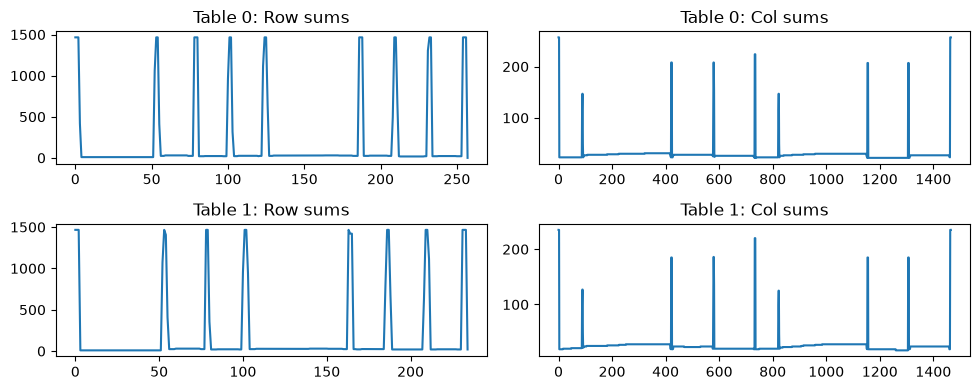

In [520]:
cols = 2
rows = len(list_mask_finaly)

fig, axes = plt.subplots(rows, cols, figsize=(10, 2 * rows))
axes = np.atleast_2d(axes)

total_sum_rows = []
total_sum_cols = []

for i, mask_finaly in enumerate(list_mask_finaly):
    row_sums = (mask_finaly > 0).sum(axis=1)
    col_sums = (mask_finaly > 0).sum(axis=0)
    total_sum_rows.append(row_sums)
    total_sum_cols.append(col_sums)

    ax_rows, ax_cols = axes[i, 0], axes[i, 1]

    ax_rows.plot(row_sums)
    ax_rows.set_title(f"Table {i}: Row sums")

    ax_cols.plot(col_sums)
    ax_cols.set_title(f"Table {i}: Col sums")

plt.tight_layout()
plt.show()


In [521]:
from scipy.signal import find_peaks

def find_lines_with_edges(sums, distance, prominence_frac, edge_check_width=5, edge_frac=0.5):

    # distance — минимальное расстояние между соседними пиками (линии сетки не могут быть ближе N px)
    # prominence — насколько пик должен выделяться над локальным окружением (не абсолютное число!)
    peaks, _ = find_peaks(sums, distance=distance, prominence=sums.max() * prominence_frac)
    peaks = list(peaks)

    threshold = sums.max() * edge_frac

    # начало профиля
    if not peaks or peaks[0] > edge_check_width:
        if sums[:edge_check_width].max() > threshold:
            peaks.insert(0, int(np.argmax(sums[:edge_check_width])))
        else:
            peaks.insert(0, 0)  # виртуальная граница — линии нет, но это край таблицы

    # конец профиля
    if not peaks or peaks[-1] < len(sums) - edge_check_width:
        if sums[-edge_check_width:].max() > threshold:
            peaks.append(len(sums) - edge_check_width + int(np.argmax(sums[-edge_check_width:])))
        else:
            peaks.append(len(sums) - 1)  # виртуальная граница

    return sorted(peaks)

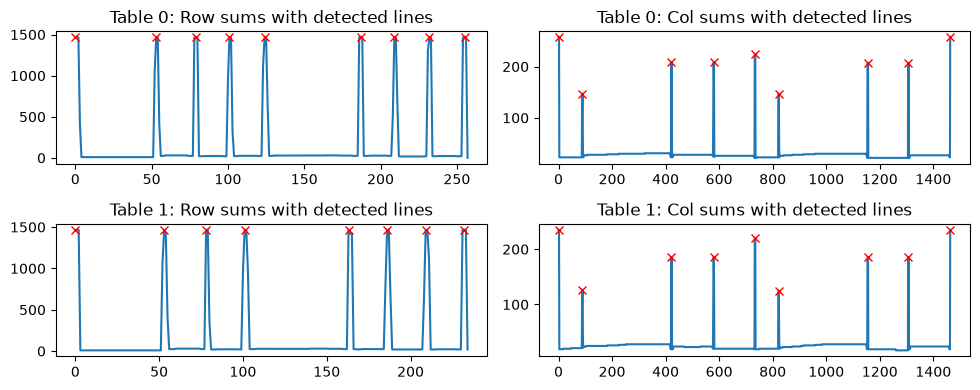

In [522]:
cols = 2
rows = len(list_mask_finaly)

fig, axes = plt.subplots(rows, cols, figsize=(10, 2 * rows))
axes = np.atleast_2d(axes)

total_row_peaks = []
total_col_peaks = []

for i, (row_sums, col_sums) in enumerate(zip(total_sum_rows, total_sum_cols)):
    row_peaks = find_lines_with_edges(row_sums, distance=10, prominence_frac=0.2)
    col_peaks = find_lines_with_edges(col_sums, distance=4, prominence_frac=0.2)

    total_row_peaks.append(row_peaks)
    total_col_peaks.append(col_peaks)

    ax_rows, ax_cols = axes[i, 0], axes[i, 1]
    ax_rows.plot(row_sums)
    ax_rows.plot(row_peaks, row_sums[row_peaks], "rx")
    ax_rows.set_title(f"Table {i}: Row sums with detected lines")
    ax_cols.plot(col_sums)
    ax_cols.plot(col_peaks, col_sums[col_peaks], "rx")
    ax_cols.set_title(f"Table {i}: Col sums with detected lines")

plt.tight_layout()
plt.show()



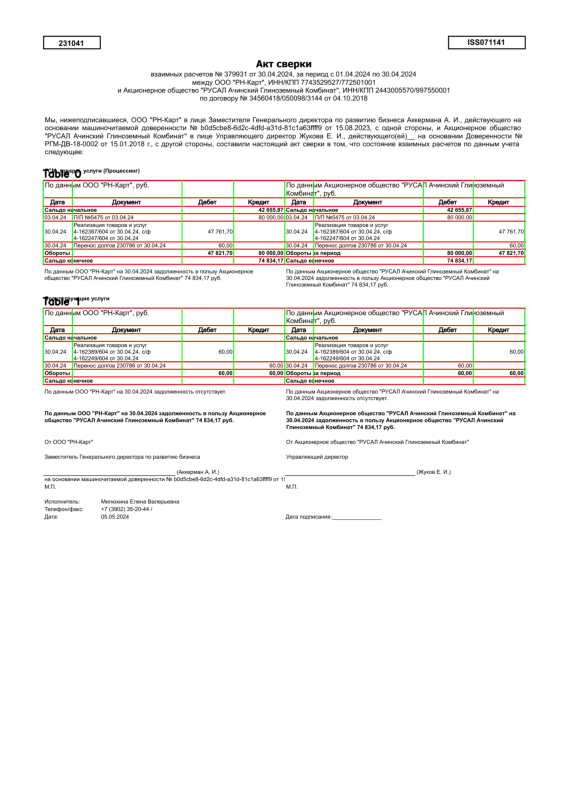

In [523]:
vis_grid = img.copy()
for i, ((x, y, w, h), row_peaks, col_peaks) in enumerate(zip(table_candidates, total_row_peaks, total_col_peaks)):
    crop_h, crop_w = h, w
    for ly in row_peaks:
        x0 = x + 0
        x1 = x + crop_w
        y0 = y + ly
        y1 = y + ly
        cv2.line(vis_grid, (x0, y0), (x1, y1), (255, 0, 0), 2)
    for lx in col_peaks:
        x0 = x + lx
        x1 = x + lx
        y0 = y + 0
        y1 = y + crop_h
        cv2.line(vis_grid, (x0, y0), (x1, y1), (0, 255, 0), 2)
    cv2.putText(vis_grid, f"Table {i}", (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 0, 0), 3)


plt.figure(figsize=(10, 10))
plt.imshow(vis_grid)
plt.axis("off")
plt.show()

In [524]:
def detect_vertical_borders(no_text, row_peaks, col_peaks, tolerance=8, peak_prominence_frac=0.3):
    n_rows = len(row_peaks) - 1
    is_vborder = np.zeros((n_rows, len(col_peaks)), dtype=bool)
    for i in range(n_rows):
        y0, y1 = row_peaks[i], row_peaks[i + 1]
        strip = no_text[y0:y1, :].sum(axis=0)
        if strip.max() == 0:
            continue
        threshold = strip.max() * peak_prominence_frac
        for j, lx in enumerate(col_peaks):
            lo, hi = max(0, lx - tolerance), min(len(strip), lx + tolerance + 1)
            is_vborder[i, j] = strip[lo:hi].max() >= threshold
    return is_vborder


def detect_horizontal_borders(no_text, row_peaks, col_peaks, tolerance=5, peak_prominence_frac=0.3):
    n_cols = len(col_peaks) - 1
    is_hborder = np.zeros((len(row_peaks), n_cols), dtype=bool)
    for j in range(n_cols):
        x0, x1 = col_peaks[j], col_peaks[j + 1]
        strip = no_text[:, x0:x1].sum(axis=1)
        if strip.max() == 0:
            continue
        threshold = strip.max() * peak_prominence_frac
        for i, ly in enumerate(row_peaks):
            lo, hi = max(0, ly - tolerance), min(len(strip), ly + tolerance + 1)
            is_hborder[i, j] = strip[lo:hi].max() >= threshold
    return is_hborder


In [525]:
def debug_vertical_borders(no_text_safe, row_peaks, col_peaks, is_vborder, tolerance=10):
    n_rows = len(row_peaks) - 1
    fig, axes = plt.subplots(n_rows, 2, figsize=(14, 3 * n_rows))
    axes = np.atleast_2d(axes)

    for i in range(n_rows):
        y0, y1 = row_peaks[i], row_peaks[i + 1]
        strip_img = no_text_safe[y0:y1, :]
        strip_sum = strip_img.sum(axis=0)

        ax_img, ax_profile = axes[i, 0], axes[i, 1]
        ax_img.imshow(strip_img, cmap="gray", aspect="auto")
        ax_img.set_title(f"Col band {i}: mask [{y0}:{y1}]")
        ax_img.axis("off")

        ax_profile.plot(strip_sum)
        for j, lx in enumerate(col_peaks):
            color = "g" if is_vborder[i, j] else "r"
            ax_profile.axvline(lx, color=color, linestyle="dashed", linewidth=1)
            lo, hi = max(0, lx - tolerance), min(len(strip_sum), lx + tolerance + 1)
            ax_profile.axvspan(lo, hi, color=color, alpha=0.15)
        ax_profile.set_title(f"Col band {i}: col profile (green=confirmed, red=not)")

    fig.tight_layout()
    plt.show()


def debug_horizontal_borders(no_text_safe, row_peaks, col_peaks, is_hborder, tolerance=5):
    n_cols = len(col_peaks) - 1
    fig, axes = plt.subplots(n_cols, 2, figsize=(14, 3 * n_cols))
    axes = np.atleast_2d(axes)

    for j in range(n_cols):
        x0, x1 = col_peaks[j], col_peaks[j + 1]
        strip_img = no_text_safe[:, x0:x1]
        strip_sum = strip_img.sum(axis=1)

        ax_img, ax_profile = axes[j, 0], axes[j, 1]
        ax_img.imshow(strip_img, cmap="gray", aspect="auto")
        ax_img.set_title(f"Row band {j}: mask [{x0}:{x1}]")
        ax_img.axis("off")

        ax_profile.plot(strip_sum)
        for i, ly in enumerate(row_peaks):
            color = "g" if is_hborder[i, j] else "r"
            ax_profile.axvline(ly, color=color, linestyle="dashed", linewidth=1)
            lo, hi = max(0, ly - tolerance), min(len(strip_sum), ly + tolerance + 1)
            ax_profile.axvspan(lo, hi, color=color, alpha=0.15)
        ax_profile.set_title(f"Row band {j}: row profile (green=confirmed, red=not)")

    fig.tight_layout()
    plt.show()


In [526]:
# i = 2
# row_peaks = total_row_peaks[i]
# col_peaks = total_col_peaks[i]
# no_text_safe = list_mask_finaly[i]

# h_tolerance = 5
# v_tolerance = 20


# is_vborder = detect_vertical_borders(no_text_safe, row_peaks, col_peaks, tolerance=v_tolerance, peak_prominence_frac=0.3)
# is_hborder = detect_horizontal_borders(no_text_safe, row_peaks, col_peaks, tolerance=h_tolerance, peak_prominence_frac=0.2)

# debug_vertical_borders(no_text_safe, row_peaks, col_peaks, is_vborder, tolerance=v_tolerance)
# debug_horizontal_borders(no_text_safe, row_peaks, col_peaks, is_hborder, tolerance=h_tolerance)


In [527]:
vis_grid_borders = img.copy()

for i, ((x, y, w, h), no_text_safe) in enumerate(zip(table_candidates, list_mask_finaly)):
    row_peaks = total_row_peaks[i]
    col_peaks = total_col_peaks[i]

    is_vborder = detect_vertical_borders(no_text_safe, row_peaks, col_peaks, 
                                         tolerance=20, peak_prominence_frac=0.2)
    is_hborder = detect_horizontal_borders(no_text_safe, row_peaks, col_peaks, 
                                           tolerance=5, peak_prominence_frac=0.2)

    n_rows = len(row_peaks) - 1
    n_cols = len(col_peaks) - 1

    # горизонтальные отрезки: строка-пик r, столбец-сегмент c
    for r, ly in enumerate(row_peaks):
        for c in range(n_cols):
            if not is_hborder[r, c]:
                x0, x1 = x + col_peaks[c], x + col_peaks[c + 1]
                y0 = y + ly
                cv2.line(vis_grid_borders, (x0, y0), (x1, y0), (255, 0, 0), 2)

    # вертикальные отрезки: столбец-пик c, строка-сегмент r
    for c, lx in enumerate(col_peaks):
        for r in range(n_rows):
            if not is_vborder[r, c]:
                y0, y1 = y + row_peaks[r], y + row_peaks[r + 1]
                x0 = x + lx
                cv2.line(vis_grid_borders, (x0, y0), (x0, y1), (0, 255, 0), 2)

# plt.figure(figsize=(10, 10))
# plt.imshow(vis_grid_borders)
# plt.axis("off")
# plt.show()


In [528]:
from vision_core.entities.bbox import BBox
from vision_core.entities.cell import Cell
from vision_core.entities.table import Table


def build_table_entity(table_bbox, labels, row_peaks, col_peaks, table_id):
    """Строит Table/Cell из grid-разметки (row_peaks/col_peaks/labels). Координаты ячеек — абсолютные (страница)."""
    x, y, w, h = table_bbox
    n_rows, n_cols = labels.shape

    cells = []
    for label in np.unique(labels):
        if label < 0:
            continue
        rows, cols = np.where(labels == label)
        row_min, row_max = int(rows.min()), int(rows.max())
        col_min, col_max = int(cols.min()), int(cols.max())

        cell_bbox = BBox(
            x_min=x + col_peaks[col_min],
            y_min=y + row_peaks[row_min],
            x_max=x + col_peaks[col_max + 1],
            y_max=y + row_peaks[row_max + 1],
        )

        cells.append(
            Cell(
                row=row_min,
                col=col_min,
                rowspan=row_max - row_min + 1,
                colspan=col_max - col_min + 1,
                value=None,
                bbox=cell_bbox,
            )
        )

    return Table(
        id=table_id,
        bbox=BBox(x_min=x, y_min=y, x_max=x + w, y_max=y + h),
        num_rows=n_rows,
        num_cols=n_cols,
        cells=cells,
    )


In [529]:
def build_merged_regions_rect_safe(is_vborder, is_hborder, n_rows, n_cols):
    # Проход 1: горизонтальные сегменты в каждой строке независимо
    row_segments = []  # список (row, col_start, col_end) на строку
    for i in range(n_rows):
        c = 0
        while c < n_cols:
            c_end = c
            while c_end + 1 < n_cols and not is_vborder[i, c_end + 1]:
                c_end += 1
            row_segments.append({"row": i, "col_start": c, "col_end": c_end})
            c = c_end + 1

    # Проход 2: сливаем сегменты вертикально, только если совпадают col_start/col_end
    # и между ними нет hborder ни в одной из колонок сегмента
    n = len(row_segments)
    parent = list(range(n))

    def find(a):
        while parent[a] != a:
            parent[a] = parent[parent[a]]
            a = parent[a]
        return a

    def union(a, b):
        ra, rb = find(a), find(b)
        if ra != rb:
            parent[ra] = rb

    by_row = {}
    for idx, seg in enumerate(row_segments):
        by_row.setdefault(seg["row"], []).append(idx)

    for idx, seg in enumerate(row_segments):
        i, cs, ce = seg["row"], seg["col_start"], seg["col_end"]
        if i + 1 >= n_rows:
            continue
        for jdx in by_row.get(i + 1, []):
            other = row_segments[jdx]
            if other["col_start"] == cs and other["col_end"] == ce:
                # проверяем, что hborder отсутствует по ВСЕЙ ширине сегмента
                if not any(is_hborder[i + 1, c] for c in range(cs, ce + 1)):
                    union(idx, jdx)

    labels = np.full((n_rows, n_cols), -1, dtype=int)
    for idx, seg in enumerate(row_segments):
        root = find(idx)
        labels[seg["row"], seg["col_start"]:seg["col_end"] + 1] = root

    return labels

def merge_thin_rows(row_peaks, min_row_height):
    """Убирает пики строк, если получившаяся строка тоньше min_row_height —
    сливает её с соседней. Верхнюю и нижнюю границу таблицы не трогает."""
    if len(row_peaks) < 3:
        return row_peaks

    merged = list(row_peaks)

    i = 1
    while i < len(merged) - 1:
        if merged[i] - merged[i - 1] < min_row_height:
            del merged[i]
        else:
            i += 1

    while len(merged) > 2 and merged[-1] - merged[-2] < min_row_height:
        del merged[-2]

    return merged



In [530]:
h_tolerance = 5
v_tolerance = 20
list_tables = []
for i, (x, y, w, h) in enumerate(table_candidates):
    row_peaks = merge_thin_rows(total_row_peaks[i], list_median_heights[i] * 0.8)
    col_peaks = total_col_peaks[i]

    is_vborder = detect_vertical_borders(list_mask_finaly[i], 
                                         row_peaks, col_peaks, tolerance=v_tolerance, 
                                         peak_prominence_frac=0.3)
    is_hborder = detect_horizontal_borders(list_mask_finaly[i], 
                                           row_peaks, col_peaks, tolerance=h_tolerance, 
                                           peak_prominence_frac=0.2)

    n_rows = len(row_peaks) - 1
    n_cols = len(col_peaks) - 1
    labels = build_merged_regions_rect_safe(is_vborder, is_hborder, n_rows, n_cols)

    table = build_table_entity((x, y, w, h), labels, row_peaks, col_peaks, table_id=f"table_{i}")
    list_tables.append(table)
    print(f"Table {i}: {table.num_rows}x{table.num_cols}, cells={len(table.cells)}")


Table 0: 8x8, cells=51
Table 1: 7x8, cells=44


In [531]:
def has_missing_text(content_mask: np.ndarray, min_area: int = 15, min_side: int = 4) -> bool:
    """True, если в content_mask есть остаточный регион (нераспознанный текст)."""
    n, labels, stats, _ = cv2.connectedComponentsWithStats(content_mask)
    for label in range(1, n):
        area = stats[label, cv2.CC_STAT_AREA]
        w, h = stats[label, cv2.CC_STAT_WIDTH], stats[label, cv2.CC_STAT_HEIGHT]
        if area < min_area or w < min_side or h < min_side:
            continue
        return True
    return False

def has_overflowing_text(cell_bbox: BBox, ocr_blobs: list[BBox], min_containment_ratio: float = 0.95) -> bool:
    """True, если среди блобов, назначенных ячейке, есть такой, что не помещается в неё целиком."""
    for ocr_bbox in ocr_blobs:
        if ocr_bbox.area == 0:
            continue
        if cell_bbox.intersect(ocr_bbox) / ocr_bbox.area < min_containment_ratio:
            return True
    return False


def assign_blobs_to_cells(cells: list[Cell], ocr_results: list[BBox], min_overlap_ratio: float = 0.1, confidence_threshold: float = 0.7) -> dict[int, list[BBox]]:
    """Распределяет OCR-результаты по ячейкам — каждый блок достаётся ячейке
    с максимальной долей перекрытия (BBox.intersect / ocr_area)."""
    cell_ocr = {id(c): [] for c in cells}

    for r in ocr_results:
        if r.confidence < confidence_threshold:
            continue
        ocr_bbox = BBox.from_tuple(r.bbox)
        if ocr_bbox.area == 0:
            continue

        best_cell, best_ratio = None, min_overlap_ratio
        for cell in cells:
            ratio = ocr_bbox.intersect(cell.bbox) / ocr_bbox.area
            if ratio > best_ratio:
                best_ratio, best_cell = ratio, cell

        if best_cell is not None:
            cell_ocr[id(best_cell)].append(r)

    return cell_ocr


def find_reocr_cells(cells, cell_ocr, min_containment_ratio=0.8, min_overlap_ratio=0.1):
    """Ячейки, где OCR слепил текст нескольких ячеек, + соседи, которых заметно
    (не на пару случайных пикселей, а по-настоящему) задевает тот же блок."""
    reocr_ids = set()

    for cell in cells:
        blobs = [BBox.from_tuple(r.bbox) for r in cell_ocr[id(cell)]]
        if not has_overflowing_text(cell.bbox, blobs, min_containment_ratio):
            continue
        reocr_ids.add(id(cell))

        for blob in blobs:
            if blob.area == 0 or cell.bbox.intersect(blob) / blob.area >= min_containment_ratio:
                continue  # этот конкретный блок не переполняет — не он виноват
            for other in cells:
                if id(other) != id(cell) and other.bbox.intersect(blob) / blob.area >= min_overlap_ratio:
                    reocr_ids.add(id(other))

    return [cell for cell in cells if id(cell) in reocr_ids]


def find_missing_text_cells(cells, content_mask, tx, ty, min_area=50, min_side=7):
    """Ячейки, где после вычитания OCR-текста и линий сетки остались
    нераспознанные пиксели — OCR пропустил текст в этой ячейке."""
    missing = []
    for cell in cells:
        cx0, cy0, cx1, cy1 = cell.bbox.to_tuple()
        crop = content_mask[cy0 - ty:cy1 - ty, cx0 - tx:cx1 - tx]
        if has_missing_text(crop, min_area=min_area, min_side=min_side):
            missing.append(cell)
    return missing


def fill_cell_values(cells: list[Cell], cell_ocr: dict[int, list[BBox]]) -> None:
    """Заполняет value и blobs каждой ячейки из назначенных ей OCR-результатов."""
    for cell in cells:
        items = cell_ocr[id(cell)]
        cell.value = "\n".join(r.text for r in items)
        cell.blobs = [BBox.from_tuple(r.bbox) for r in items]


def reocr_cells(cells, img, ocr_engine, confidence_threshold=0.7):
    """Перезапускает OCR по кропу для переданных ячеек и перезаписывает их value."""
    for cell in cells:
        crop = cell.bbox.roi(img)
        if crop.size == 0:
            cell.value = ""
            cell.blobs = []
            continue

        results = ocr_engine.predict(crop)
        cell_results = results[0] if results else []
        texts = [r.text for r in cell_results if r.confidence >= confidence_threshold]

        cell.value = " ".join(texts)
        cell.blobs = []
        print(f"Re-OCR R{cell.row}:C{cell.col} -> {cell.value!r}")


In [532]:
def print_cell_grid(cells):
    """Печатает содержимое всех ячеек в виде текстового списка R:C -> value — для отладки заполнения."""
    for cell in sorted(cells, key=lambda c: (c.row, c.col)):
        span = f"({cell.rowspan}x{cell.colspan})" if cell.rowspan > 1 or cell.colspan > 1 else ""
        print(f"R{cell.row}:C{cell.col}{span} -> {cell.value!r}")


def draw_cell_values(draw, cells, font):
    """Рисует value каждой ячейки поверх её bbox на изображении — для визуальной отладки."""
    for cell in cells:
        cx0, cy0, cx1, cy1 = cell.bbox.to_tuple()
        text = (cell.value or "").replace("\n", " / ")
        draw.text((cx0 + 3, cy0 + 3), text, fill=(200, 0, 0, 255), font=font)

def draw_ocr_boxes(draw, ocr_results, outline=(0, 0, 255, 255), width=1):
    """Рисует все сырые OCR-боксы — для сверки с границами ячеек."""
    for r in ocr_results:
        ox0, oy0, ox1, oy1 = r.bbox
        draw.rectangle([ox0, oy0, ox1, oy1], outline=outline, width=width)


def draw_cell_grid(draw, cells, outline=(128, 128, 128, 255), width=1):
    """Рисует границы всех ячеек таблицы — тонким контуром."""
    for cell in cells:
        cx0, cy0, cx1, cy1 = cell.bbox.to_tuple()
        draw.rectangle([cx0, cy0, cx1, cy1], outline=outline, width=width)


In [533]:
from PIL import Image, ImageDraw, ImageFont

font = ImageFont.load_default(size=16)
base = Image.fromarray(img.copy()).convert("RGBA")
overlay = Image.new("RGBA", base.size, (0, 0, 0, 0))
draw = ImageDraw.Draw(overlay)

for i, table in enumerate(list_tables):
    tx, ty = int(table.bbox.x_min), int(table.bbox.y_min)
    residual = cv2.bitwise_and(list_no_text[i], cv2.bitwise_not(list_text_masks[i]))
    content_mask = cv2.bitwise_and(residual, cv2.bitwise_not(list_mask_finaly[i]))

    cell_ocr = assign_blobs_to_cells(table.cells, ocr_results, min_overlap_ratio=0.1, confidence_threshold=0.4)
    overflow_cells = find_reocr_cells(table.cells, cell_ocr, min_containment_ratio=0.7)
    missing_cells = find_missing_text_cells(table.cells, content_mask, tx, ty, min_area=150, min_side=7)

    fill_cell_values(table.cells, cell_ocr)

    cells_to_reocr = list({id(c): c for c in overflow_cells + missing_cells}.values())
    reocr_cells(cells_to_reocr, img, build_pipeline.ocr_engine, confidence_threshold=0.4)

    print(f"--- Table {i} ---")
    # print_cell_grid(table.cells)

    overflow_ids = {id(c) for c in overflow_cells}
    missing_ids = {id(c) for c in missing_cells}

    draw_cell_grid(draw, table.cells)
    for cell in table.cells:
        cx0, cy0, cx1, cy1 = cell.bbox.to_tuple()
        if id(cell) in missing_ids:
            draw.rectangle((cx0, cy0, cx1, cy1), outline=(255, 0, 0, 255), fill=(255, 0, 0, 90), width=2)
        if id(cell) in overflow_ids:
            draw.rectangle((cx0, cy0, cx1, cy1), outline=(0, 255, 0, 255), fill=(0, 255, 0, 90), width=2)

draw_ocr_boxes(draw, ocr_results)

vis_status = Image.alpha_composite(base, overlay).convert("RGB")
vis_status.show()


Re-OCR R6:C3 -> '80 000,00'
Re-OCR R6:C4 -> 'Обороты за период'
--- Table 0 ---
Re-OCR R4:C3 -> '60,00'
Re-OCR R4:C4 -> '30.04.24'
--- Table 1 ---


In [534]:
def find_merge_candidates(tables, median_heights, x_overlap_thr=0.9, max_gap_in_medians=2.0):
    """Находит пары соседних по вертикали таблиц с совпадающим числом столбцов,
    высоким перекрытием по x и разрывом не больше max_gap_in_medians медиан высоты строки."""
    merge_pairs = []
    for i in range(len(tables) - 1):
        a, b = tables[i], tables[i + 1]

        x_overlap = max(0, min(a.bbox.x_max, b.bbox.x_max) - max(a.bbox.x_min, b.bbox.x_min))
        if x_overlap / min(a.bbox.width, b.bbox.width) < x_overlap_thr:
            continue
        if a.num_cols != b.num_cols:
            continue

        gap = b.bbox.y_min - a.bbox.y_max
        if gap > max_gap_in_medians * max(median_heights[i], median_heights[i + 1]):
            continue

        merge_pairs.append((i, i + 1))
    return merge_pairs

def merge_table_groups(tables, merge_pairs):
    """Объединяет таблицы в группы через union-find, сдвигая row у ячеек
    нижних таблиц и склеивая их в одну Table."""
    n = len(tables)
    parent = list(range(n))

    def find(a):
        while parent[a] != a:
            parent[a] = parent[parent[a]]
            a = parent[a]
        return a

    def union(a, b):
        ra, rb = find(a), find(b)
        if ra != rb:
            parent[ra] = rb

    for i, j in merge_pairs:
        union(i, j)

    groups: dict[int, list[int]] = {}
    for idx in range(n):
        groups.setdefault(find(idx), []).append(idx)

    merged = []
    for indices in groups.values():
        indices.sort(key=lambda idx: tables[idx].bbox.y_min)
        group = [tables[idx] for idx in indices]

        cells = []
        row_offset = 0
        for t in group:
            cells.extend(cell.model_copy(update={"row": cell.row + row_offset}) for cell in t.cells)
            row_offset += t.num_rows

        merged.append(Table(
            id=group[0].id,
            bbox=BBox(
                x_min=min(t.bbox.x_min for t in group),
                y_min=min(t.bbox.y_min for t in group),
                x_max=max(t.bbox.x_max for t in group),
                y_max=max(t.bbox.y_max for t in group),
            ),
            num_rows=sum(t.num_rows for t in group),
            num_cols=group[0].num_cols,
            cells=cells,
        ))
    return merged


In [535]:
valid = [i for i, t in enumerate(list_tables) if t.is_valid()]
list_tables = [list_tables[i] for i in valid]
list_median_heights = [list_median_heights[i] for i in valid]
# list_no_text = [list_no_text[i] for i in valid]
# list_text_masks = [list_text_masks[i] for i in valid]
# list_mask_finaly = [list_mask_finaly[i] for i in valid]


merge_pairs = find_merge_candidates(list_tables, list_median_heights, x_overlap_thr=0.8, max_gap_in_medians=3)
list_tables = merge_table_groups(list_tables, merge_pairs)

In [536]:
from PIL import Image, ImageDraw, ImageFont

vis_copy = img.copy()
base = Image.fromarray(vis_copy).convert("RGBA")
overlay = Image.new("RGBA", base.size, (0, 0, 0, 0))
draw = ImageDraw.Draw(overlay)
font = ImageFont.load_default(size=m // 2)

palette = [
    (255, 99, 71), (60, 179, 113), (65, 105, 225), (255, 165, 0),
    (147, 112, 219), (0, 206, 209), (220, 20, 60), (154, 205, 50),
]

for table in list_tables:
    for idx, cell in enumerate(table.cells):
        x0, y0, x1, y1 = cell.bbox.to_tuple()
        r, g, b = palette[idx % len(palette)]
        draw.rectangle([x0, y0, x1, y1], outline=(0, 0, 0, 255), width=3, fill=(r, g, b, 90))
        draw.text((x0 + 5, y0 + 5), f"R{cell.row}:C{cell.col}", fill=(0, 0, 0, 255), font=font)

vis_grid_merged = Image.alpha_composite(base, overlay).convert("RGB")
vis_grid_merged.show()
